# South Atlantic Geomagnetic Field — ML Surrogate Model & Anomaly Mapping

**What this project does:** It takes a regional grid of
Earth's magnetic field over the South Atlantic (built from the IGRF-12
reference model), trains a machine-learning model that reconstructs the
field as a smooth, continuous surface, and applies standard exploration-geophysics
techniques anomaly localisation, regional-residual separation, and
horizontal-gradient (edge) mapping to turn that surface into the kind of
product a magnetic-survey interpreter actually works with.

## Why this matters, and who uses it

Magnetic surveying is one of the oldest and cheapest geophysical exploration
tools in the oil & gas industry. Before a single seismic line is shot or a
well is drilled, magnetic data is used to:

- **Map basement depth and structure** Magnetic anomalies are dominated by
  magnetic minerals in crystalline basement rock, which is magnetically
  "loud" compared to the sedimentary rocks above it. Mapping how the field
  varies spatially tells you how deep the basement is and where it is
  structurally offset.
- **Locate faults and structural boundaries** Abrupt changes in the
  magnetic field (steep gradients) often mark faults, intrusions, or
  basement highs/lows that can control where hydrocarbons migrate and
  accumulate.
- **Prioritise areas for expensive follow-up surveys** Seismic acquisition
  costs orders of magnitude more per square kilometre than a magnetic
  survey. Magnetic and gravity data are used first, regionally, to decide
  *where* to spend the seismic budget.
- **De-risk frontier/underexplored basins** In regions with little existing
  well control (much of the offshore South Atlantic margin included), a
  well-characterised regional magnetic field is often the first real
  structural picture geologists have to work with.

This notebook does not replace a licensed aeromagnetic survey, the IGRF
model captures the broad, planetary-scale main field, not the short-wavelength
crustal detail a real exploration survey measures. What it *does* demonstrate
is the analytical workflow gridding, interpolation, anomaly detection,
regional-residual separation, gradient mapping using machine learning
instead of the classical hand-contouring or deterministic-gridding tools
still common in the industry, on real geomagnetic field data.

## Pipeline in this notebook
1. Parse the raw IGRF spreadsheet into a tidy dataset
2. Explore and visualise the raw data (multiple charts, each explained)
3. Screen out physically impossible values
4. Train and compare two ML models (Random Forest vs. Gaussian Process)
5. Interpolate the field at high resolution and locate the South Atlantic Anomaly (SAA)
6. **Regional-residual separation** — isolate local anomalies from the broad regional trend
7. **Horizontal gradient mapping** — highlight edges/boundaries (the exploration-relevant product)
8. Summary and how this generalises to an oil & gas exploration workflow


In [2]:
# Data Manipulation & Array Operations
import pandas as pd  # Dataframes for loading, merging, and cleaning tabular IGRF data
import numpy as np  # Numerical computing for array manipulation and mathematical operations

# Visualization
import matplotlib.pyplot as plt  # Plotting library for diagnostic charts and anomaly maps

# Machine Learning & Surrogate Modelling
from sklearn.ensemble import (
    RandomForestRegressor,  # Baseline ensemble model for nonlinear spatial regression
)
from sklearn.gaussian_process import (
    GaussianProcessRegressor,  # Primary surrogate model (Kriging analogue) for spatial interpolation
)
from sklearn.gaussian_process.kernels import (
    RBF,  # Radial Basis Function kernel to model smooth spatial covariance
    ConstantKernel,  # Scaling factor for kernel variance
    WhiteKernel,  # Models measurement noise and absorbs small-scale errors
)

# Model Evaluation & Validation
from sklearn.metrics import (
    mean_squared_error,  # Metric used to calculate Root Mean Squared Error (RMSE)
)
from sklearn.model_selection import (
    KFold,  # Cross-validation strategy to evaluate out-of-sample performance
)

# Plot Configuration
plt.rcParams["figure.dpi"] = 110  # Set higher DPI for crisp inline figures

## Step 1: Parse the raw IGRF spreadsheet into a tidy dataset

The source file (`igrf_data.xlsx`) was built for a person to read, not for a
model to consume: each geomagnetic component lives on its own sheet, and each
sheet stacks **two** grids on top of each other (the mean field value, then
its annual rate of change / secular variation), separated by blank rows. This
step reshapes it into "long" (tidy) format: one row per (latitude, longitude)
grid point, one column per physical quantity.

**Grid geometry:** latitude 20° down to -60° (5° steps, 17 rows), longitude
-80° to 40° (5° steps, 25 columns) = 425 grid points, epoch 2018.0, sea level.

**The seven physical quantities extracted:**
- **F** — total field intensity (nT): the overall strength of the magnetic field.
- **Z** — vertical component (nT): downward-pointing part of the field.
- **X, Y** — north and east horizontal components (nT).
- **H** — horizontal intensity (nT): combined strength of X and Y.
- **D, I** — declination and inclination (angles): the field's direction. Only their
  secular variation (rate of change, minutes/year) is parsed here; their mean values
  are stored as inconsistent degree-minute text in the source file (see the project
  report for why that was left as a documented next step rather than guessed at).


In [4]:
# # Path to the raw IGRF spreadsheet. Update this to point at your local
# # copy of igrf_data.xlsx before running.

SOURCE_PATH = r"C:\Users\DONATUS\Desktop\PhD-plan\latest IGRF15\igrf data.xlsx"

# # Every sheet uses the same 25 longitude columns
LON_COLS = list(range(2, 27))


def extract_grid(df, lon_header_row, data_start_row, data_end_row):
    """
    Pull ONE lat x lon numeric grid out of a raw (header=None) sheet and
    reshape it into tidy long format: columns = ['lat', 'lon', 'value'].
    """
#     # Row labels (latitudes) sit in column B; column headers (longitudes)
#     # sit in a single header row above the data block.
    lats = df.iloc[data_start_row:data_end_row, 1].astype(float).values
    lons = df.iloc[lon_header_row, LON_COLS].astype(float).values

#     # Coerce to numeric; anything non-numeric becomes NaN instead of
#     # raising, so malformed cells surface as missing values, not crashes.
    values = (df.iloc[data_start_row:data_end_row, LON_COLS]
                .apply(pd.to_numeric, errors="coerce")
                .values)

#     # Cross every lat with every lon to build the long-format table.

    records = [
        (lat, lon, values[i, j])
        for i, lat in enumerate(lats)
        for j, lon in enumerate(lons)
    ]
    return pd.DataFrame(records, columns=["lat", "lon", "value"])

In [5]:
xls = pd.ExcelFile(SOURCE_PATH)

# Each field component lives on its own sheet, and each sheet stacks a
# mean-value grid on top of a secular-variation (SV) grid.
component_sheets = {
    "Sheet5.": "F", "Sheet6.": "Z", "Sheet7.": "Y", "sheet8.": "X", "Sheet9.": "H",
}

# Extract the mean-value and SV grid from every component sheet.
frames = {}
for sheet_name, component in component_sheets.items():
    raw = xls.parse(sheet_name, header=None)
    mean_grid = extract_grid(raw, lon_header_row=2, data_start_row=3, data_end_row=20)
    sv_grid = extract_grid(raw, lon_header_row=23, data_start_row=24, data_end_row=41)
    frames[component] = mean_grid.rename(columns={"value": component})
    frames[component + "_sv"] = sv_grid.rename(columns={"value": component + "_sv"})

# Declination and inclination SV live on their own separate sheets.
d_sv_raw = xls.parse("Sheet10", header=None)
d_sv = extract_grid(d_sv_raw, lon_header_row=3, data_start_row=4, data_end_row=21).rename(columns={"value": "D_sv"})

i_sv_raw = xls.parse("Sheet11.", header=None)
i_sv = extract_grid(i_sv_raw, lon_header_row=4, data_start_row=5, data_end_row=22).rename(columns={"value": "I_sv"})

# Join every component back onto a single row-per-grid-point table.
merged = frames["F"]
for component in ["F_sv", "Z", "Z_sv", "Y", "Y_sv", "X", "X_sv", "H", "H_sv"]:
    merged = merged.merge(frames[component], on=["lat", "lon"])
merged = merged.merge(d_sv, on=["lat", "lon"]).merge(i_sv, on=["lat", "lon"])

print(f"Parsed grid shape: {merged.shape[0]} points x {merged.shape[1]} columns")
missing = merged.isna().sum()
if missing.any():
    print("WARNING - unparseable (NaN) cells found:")
    print(missing[missing > 0])

# Persist the tidy table so later steps can start from a clean CSV.
merged.to_csv("igrf_south_atlantic_clean.csv", index=False)
merged.head()

Parsed grid shape: 425 points x 14 columns


,lat,lon,F,F_sv,Z,Z_sv,Y,Y_sv,X,X_sv,H,H_sv,D_sv,I_sv
0,20.0,-80.0,40112.0,-110.9,30156.0,-134.9,-2735.0,-53.4,26307.0,-20.2,26448.0,-14.5,-6.7,-7.2
1,20.0,-75.0,39456.0,-112.1,29243.0,-148.6,-4101.0,-44.0,26168.0,-10.0,26487.0,-3.1,-8.5,-5.8
2,20.0,-70.0,38664.0,-110.0,27981.0,-159.0,-5347.0,-32.2,26141.0,0.5,26683.0,7.0,-10.2,-4.0
3,20.0,-65.0,37799.0,-104.8,26424.0,165.4,-6411.0,-18.5,26257.0,10.8,27029.0,14.9,-11.7,-2.0
4,20.0,-60.0,36927.0,-96.3,24636.0,-167.5,-7240.0,-3.7,26537.0,20.1,27507.0,20.4,-12.9,0.2


In [6]:
# Sanity check: expect 425 rows (17 lat x 25 lon) and one column per field.
merged.shape

(425, 14)

In [7]:
# top five rows
merged.head(10)

,lat,lon,F,F_sv,Z,Z_sv,Y,Y_sv,X,X_sv,H,H_sv,D_sv,I_sv
0,20.0,-80.0,40112.0,-110.90,30156.0,-134.9,-2735.0,-53.4,26307.0,-20.2,26448.0,-14.5,-6.7,-7.2
1,20.0,-75.0,39456.0,-112.10,29243.0,-148.6,-4101.0,-44.0,26168.0,-10.0,26487.0,-3.1,-8.5,-5.8
2,20.0,-70.0,38664.0,-110.00,27981.0,-159.0,-5347.0,-32.2,26141.0,0.5,26683.0,7.0,-10.2,-4.0
3,20.0,-65.0,37799.0,-104.80,26424.0,165.4,-6411.0,-18.5,26257.0,10.8,27029.0,14.9,-11.7,-2.0
4,20.0,-60.0,36927.0,-96.30,24636.0,-167.5,-7240.0,-3.7,26537.0,20.1,27507.0,20.4,-12.9,0.2
5,20.0,-55.0,36112.0,-85.02,22696.0,-165.0,-7793.0,11.4,26986.0,27.9,28089.0,11.4,-13.7,2.3
6,20.0,-50.0,35413.0,-71.40,20691.0,-157.9,-8043.0,25.8,27591.0,33.9,28740.0,25.3,-13.9,4.1
7,20.0,-45.0,34873.0,-56.50,18719.0,-146.8,-7980.0,38.6,28320.0,37.9,29423.0,26.1,-13.6,5.5
8,20.0,-40.0,34511.0,-41.20,16874.0,-132.4,-7624.0,48.7,29123.0,40.3,30104.0,26.7,-12.8,6.5
9,20.0,-35.0,34323.0,-26.30,15234.0,-116.0,-7011.0,55.6,29947.0,41.5,30757.0,27.8,-11.7,7.1


## Step 2: Explore the raw data

Before modelling, it's worth looking at the data itself — what range of
values each component covers, how they relate to each other, and where the
obvious problems are (this also motivates the cleaning step that follows).


### Chart 1 — Distribution of total intensity (F)

A histogram of every F value in the raw grid. **What to look for:** the bulk of points should cluster in a plausible physical range (roughly 20,000–40,000 nT for this region); anything far outside that range is a red flag, not a real reading.

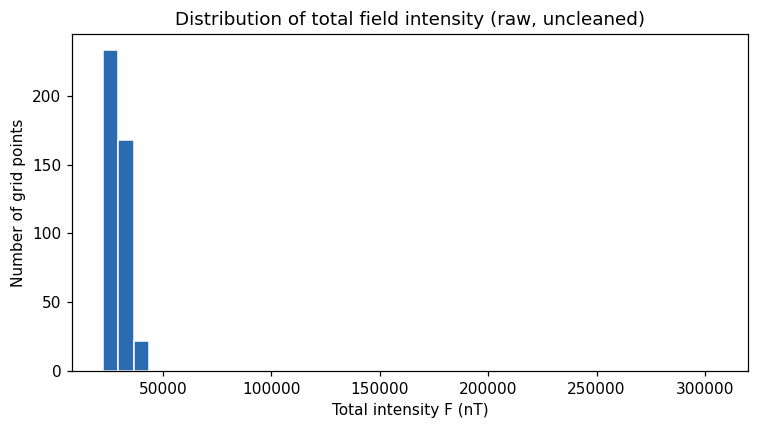

In [10]:
# Chart 1: histogram of raw F values, before any cleaning is applied.
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(merged["F"], bins=40, color="#2b6cb0", edgecolor="white")
ax.set_xlabel("Total intensity F (nT)")
ax.set_ylabel("Number of grid points")
ax.set_title("Distribution of total field intensity (raw, uncleaned)")
plt.tight_layout()
plt.savefig("chart1_F_histogram.png", dpi=140)
plt.show()

**Reading this chart:** most values sit in a tight, physically sensible cluster — but the x-axis is stretched out by a couple of extreme values sitting far to the right, well beyond anywhere Earth's field actually reaches. Those are the transcription errors this project deliberately screens out in Step 4, and this histogram is exactly how you'd first notice them in real practice.

### Chart 2 — Correlation between field components

A heatmap showing how strongly each physical quantity is correlated with the others. **Why this matters for exploration:** F, Z, X, and H are not independent — F² = X² + Y² + Z² by definition — so we expect them to be tightly correlated. A correlation matrix is a quick sanity check that the parsed data behaves the way physics says it should, before any modelling happens.

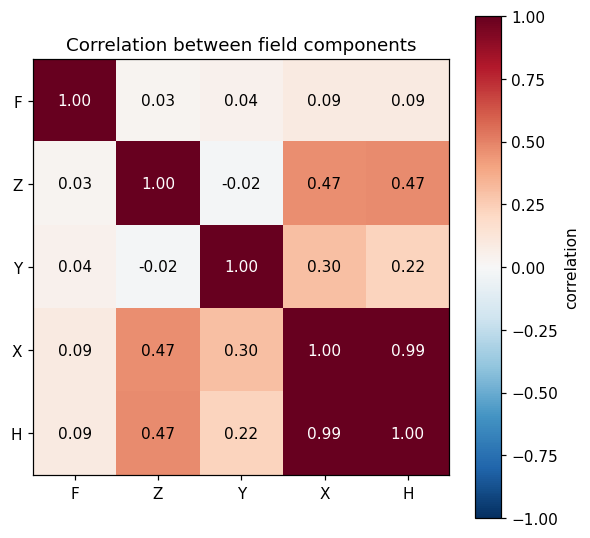

In [13]:
# Chart 2: pairwise correlation between the field components.
components = ["F", "Z", "Y", "X", "H"]
corr = merged[components].corr()

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(components))); ax.set_xticklabels(components)
ax.set_yticks(range(len(components))); ax.set_yticklabels(components)
# Annotate each cell with its correlation value.
for i in range(len(components)):
    for j in range(len(components)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
ax.set_title("Correlation between field components")
plt.colorbar(im, ax=ax, label="correlation")
plt.tight_layout()
plt.savefig("chart2_correlation_heatmap.png", dpi=140)
plt.show()

**Reading this chart:** F, Z, X, and H are strongly correlated, exactly as physics predicts — they are all describing the same underlying field from different angles. Y (the east component) is the odd one out with weaker correlations, which makes sense: in this region the field points mostly north-south, so the east-west component carries different, more independent information. This is a useful confirmation that the parsed data is physically coherent, not a parsing artifact.

## Step 3: Data-quality screening

Total field intensity (F) is a physically bounded quantity: it never exceeds
roughly 65,000 nT anywhere on Earth's surface, and within this South Atlantic
window it should sit roughly in the 20,000–45,000 nT band. Any recorded value
outside a conservative 15,000–50,000 nT window is treated as a transcription
error, not a real reading, and is dropped before training — a domain-knowledge
screen, not a generic statistical outlier rule (chosen specifically because a
purely statistical rule risks discarding the real anomaly minimum itself, since
it is, by definition, an extreme value).


In [16]:
DATA_PATH = "igrf_south_atlantic_clean.csv"
TARGET = "F"
N_FOLDS = 5
RANDOM_STATE = 42
# F can never physically exceed ~65,000 nT; values outside this window
# are treated as data-entry errors rather than genuine readings.
PLAUSIBLE_F_RANGE = (15_000, 50_000)

df_raw = pd.read_csv(DATA_PATH)

# Flag and drop any grid point whose F value fails the plausibility check.
lo, hi = PLAUSIBLE_F_RANGE
bad_rows = df_raw[(df_raw[TARGET] < lo) | (df_raw[TARGET] > hi)]
if len(bad_rows):
    print(f"Dropping {len(bad_rows)} row(s) with physically implausible "
          f"{TARGET} values (likely transcription errors in the source file):")
    print(bad_rows[["lat", "lon", TARGET]].to_string(index=False))

df = df_raw.drop(bad_rows.index).reset_index(drop=True)

# Features = coordinates, target = total intensity.
X = df[["lat", "lon"]].values
y = df[TARGET].values

Dropping 2 row(s) with physically implausible F values (likely transcription errors in the source file):
  lat  lon        F
-15.0 10.0 305633.0
-45.0 20.0 261174.0


## Step 4: Train and compare candidate models

Two regression models are compared with 5-fold cross-validation:

- **Random Forest** — baseline, makes no assumption of spatial smoothness.
- **Gaussian Process (RBF kernel)** — explicitly encodes "nearby points have
  similar field strength", matching the real physics of the smoothly varying
  main field.

**Why this matters to a geoscience audience specifically:** Gaussian Process
regression is mathematically the same technique known in geostatistics as
**Kriging** the standard method petroleum geoscientists already use to
interpolate reservoir properties (porosity, permeability, structural depth)
between wells. Using a GP here is not an exotic choice; it's the same
well-understood tool, applied to a magnetic field grid instead of well logs.


In [18]:
def cross_validated_rmse(model, X, y, n_folds):
    """Fit/evaluate `model` over `n_folds` splits and return (mean, std) RMSE."""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    fold_rmses = []
    for train_idx, test_idx in kf.split(X):
        model.fit(X[train_idx], y[train_idx])
        prediction = model.predict(X[test_idx])
        fold_rmses.append(np.sqrt(mean_squared_error(y[test_idx], prediction)))
    return float(np.mean(fold_rmses)), float(np.std(fold_rmses))


# Baseline: ensemble of trees, no assumption of spatial smoothness.
random_forest = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_rmse, rf_std = cross_validated_rmse(random_forest, X, y, N_FOLDS)

# RBF kernel encodes "nearby points have similar field values";
# white-noise term absorbs small-scale measurement/transcription noise.
gp_kernel = ConstantKernel(1.0) * RBF(length_scale=[10, 10]) + WhiteKernel(noise_level=1.0)
gaussian_process = GaussianProcessRegressor(
    kernel=gp_kernel, normalize_y=True, n_restarts_optimizer=3, random_state=RANDOM_STATE)
gp_rmse, gp_std = cross_validated_rmse(gaussian_process, X, y, N_FOLDS)

print(f"Random Forest   5-fold CV RMSE: {rf_rmse:7.1f} nT (+/- {rf_std:.1f})")
print(f"Gaussian Proc.  5-fold CV RMSE: {gp_rmse:7.1f} nT (+/- {gp_std:.1f})")
print(f"{TARGET} range in cleaned data: {y.min():.0f} to {y.max():.0f} nT (mean {y.mean():.0f})")

Random Forest   5-fold CV RMSE:   590.5 nT (+/- 178.0)
Gaussian Proc.  5-fold CV RMSE:   296.2 nT (+/- 184.3)
F range in cleaned data: 22285 to 40112 nT (mean 29017)


### Chart 3 — Model comparison

A simple bar chart comparing the two models' cross-validated error. Lower is better. **Why the GP wins:** the field is smooth and continuous in reality, and the GP's assumptions match that; the Random Forest has to approximate smooth variation with a series of blocky splits, which costs it accuracy on this kind of data.

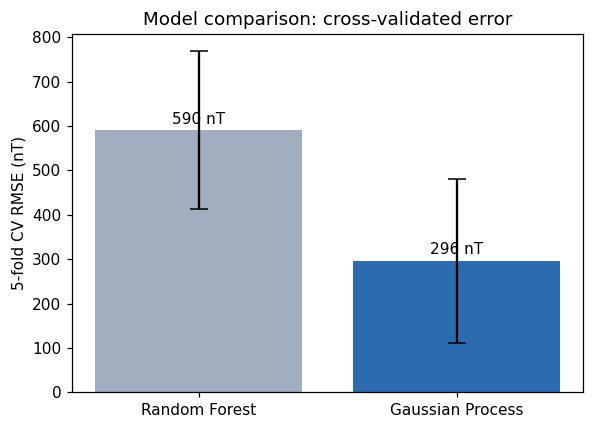

In [20]:
# Chart 3: cross-validated RMSE, Random Forest vs. Gaussian Process.
fig, ax = plt.subplots(figsize=(5.5, 4))
models = ["Random Forest", "Gaussian Process"]
rmses = [rf_rmse, gp_rmse]
stds = [rf_std, gp_std]
bars = ax.bar(models, rmses, yerr=stds, capsize=6, color=["#a0aec0", "#2b6cb0"])
ax.set_ylabel("5-fold CV RMSE (nT)")
ax.set_title("Model comparison: cross-validated error")
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, val + 15, f"{val:.0f} nT", ha="center")
plt.tight_layout()
plt.savefig("chart3_model_comparison.png", dpi=140)
plt.show()

### Regression diagnostics — predicted vs. actual, and residuals

Since this is a regression model, it's worth looking at the standard
regression diagnostic plots directly, not just the summary RMSE number.
**Important methodological point:** these plots use *out-of-sample*
predictions from cross-validation (`cross_val_predict`), not predictions on
the same data the model was trained on — fitting and predicting on the same
points would make any model look better than it really is. This is the same
standard the RMSE figures above were held to.


In [22]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score

# Out-of-sample predictions for every point (each point predicted by a
# model that never saw it during training) — used for honest diagnostics.
kf_diag = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rf_cv_pred = cross_val_predict(random_forest, X, y, cv=kf_diag)
gp_cv_pred = cross_val_predict(gaussian_process, X, y, cv=kf_diag)

rf_r2 = r2_score(y, rf_cv_pred)
gp_r2 = r2_score(y, gp_cv_pred)
print(f"Random Forest   out-of-sample R2: {rf_r2:.3f}")
print(f"Gaussian Proc.  out-of-sample R2: {gp_r2:.3f}")

Random Forest   out-of-sample R2: 0.979
Gaussian Proc.  out-of-sample R2: 0.993


### Chart 3b — Predicted vs. actual (out-of-sample)

Each point is one grid location's cross-validated prediction plotted against its true measured value. Tighter clustering around that line, and a higher R², means better predictions. The Gaussian Process points sit visibly closer to the diagonal than the Random Forest's, consistent with its lower RMSE.

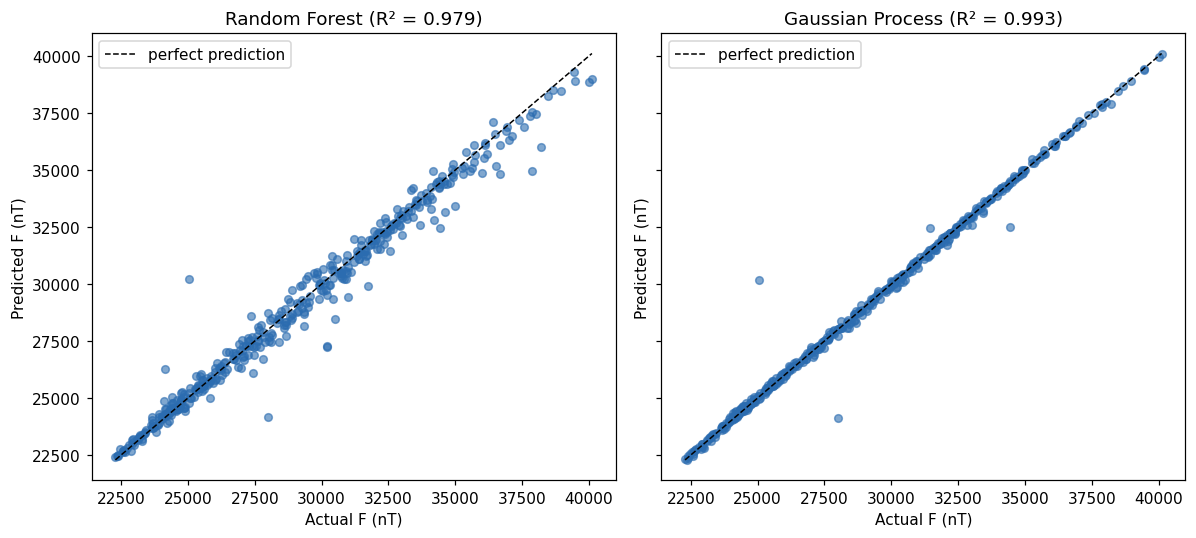

In [24]:
# Chart 3b: predicted vs. actual F, both models side by side.
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

for ax, pred, name, r2 in zip(axes, [rf_cv_pred, gp_cv_pred],
                                ["Random Forest", "Gaussian Process"], [rf_r2, gp_r2]):
    ax.scatter(y, pred, alpha=0.6, s=25, color="#2b6cb0")
    lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
    ax.plot(lims, lims, "k--", linewidth=1, label="perfect prediction")  # identity line
    ax.set_xlabel("Actual F (nT)")
    ax.set_ylabel("Predicted F (nT)")
    ax.set_title(f"{name} (R\u00b2 = {r2:.3f})")
    ax.legend()

plt.tight_layout()
plt.savefig("chart3b_predicted_vs_actual.png", dpi=140)
plt.show()

### Chart 3c — Residual plots (Gaussian Process)

Residuals are actual-minus-predicted: how far off each prediction was, and in which direction. **What to look for:** most residuals cluster tightly around zero with no obvious pattern by predicted value a good sign, since it means the model isn't systematically over- or under-predicting in any particular region of the field. **What this chart actually caught:** a handful of points (visible as isolated dots away from the main cluster, up to roughly ±5,000 nT) are still notably mis-predicted despite passing the physical-bounds screen in Step 3. These are worth a second look the bounds screen only catches values that are *physically impossible*; it won't catch a value that's merely inconsistent with its immediate neighbours. This is exactly the kind of secondary data-quality signal a residual plot is good at surfacing, on top of the more obvious problems caught earlier.

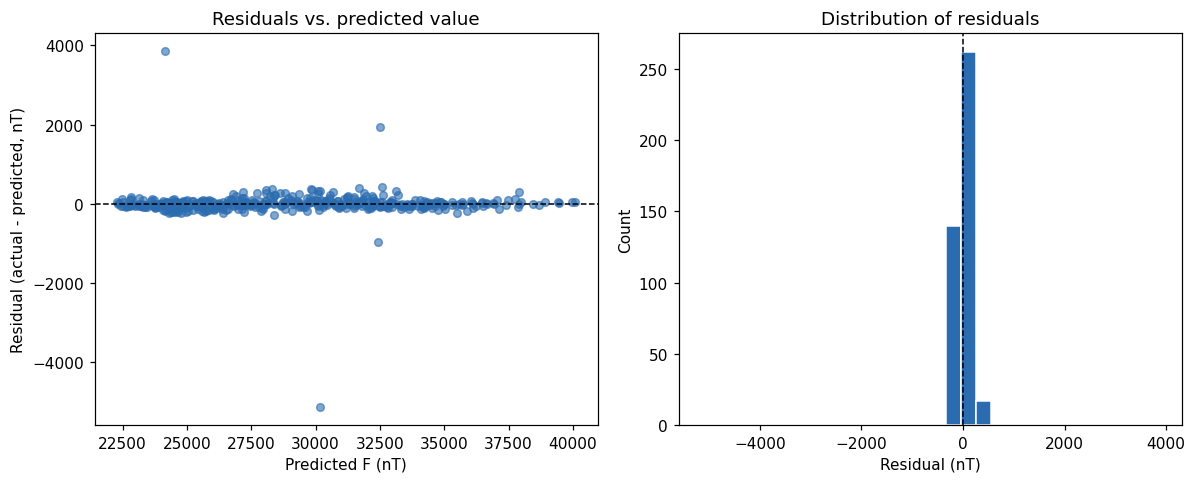

In [26]:
# Chart 3c: residual diagnostics for the selected Gaussian Process model.
gp_residuals = y - gp_cv_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: residual vs. predicted value — flags bias or heteroscedasticity.
axes[0].scatter(gp_cv_pred, gp_residuals, alpha=0.6, s=25, color="#2b6cb0")
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("Predicted F (nT)")
axes[0].set_ylabel("Residual (actual - predicted, nT)")
axes[0].set_title("Residuals vs. predicted value")

# Right: distribution of residuals — should be roughly centered at zero.
axes[1].hist(gp_residuals, bins=30, color="#2b6cb0", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_xlabel("Residual (nT)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of residuals")

plt.tight_layout()
plt.savefig("chart3c_residuals.png", dpi=140)
plt.show()

**Which points are these?** Pulling out the largest-residual points by coordinate, for anyone who wants to inspect them further:

In [28]:
# Pull out the 5 worst-predicted points for manual inspection.
residual_check = df.copy()
residual_check["gp_predicted"] = gp_cv_pred
residual_check["residual"] = gp_residuals
largest_residuals = residual_check.reindex(
    residual_check["residual"].abs().sort_values(ascending=False).index
).head(5)
largest_residuals[["lat", "lon", "F", "gp_predicted", "residual"]]

,lat,lon,F,gp_predicted,residual
58,10.0,-40.0,25036.0,30182.543760,-5146.543760
310,-40.0,-25.0,27994.0,24134.255241,3859.744759
37,15.0,-20.0,34433.0,32502.637360,1930.362640
198,-15.0,40.0,31463.0,32441.993328,-978.993328
174,-10.0,40.0,33014.0,32584.797918,429.202082


## Step 5: Interpolating the field and locating the SAA minimum

The Gaussian Process is refit on all cleaned data and used to predict F on a
fine 100 × 150 grid. The point of minimum predicted intensity is the model's
own estimate of where the South Atlantic Anomaly (SAA) is centred — found
automatically, with no prior assumption about where to look.


In [30]:
# Refit the Gaussian Process on ALL cleaned data (no held-out fold) for
# the final interpolation, since more training data means a better fit.
best_model = gaussian_process
best_model.fit(X, y)

# Build a fine 100 x 150 query grid spanning the same lat/lon extent.
lat_fine = np.linspace(df.lat.min(), df.lat.max(), 100)
lon_fine = np.linspace(df.lon.min(), df.lon.max(), 150)
lat_grid, lon_grid = np.meshgrid(lat_fine, lon_fine, indexing="ij")
query_points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
predicted_field = best_model.predict(query_points).reshape(lat_grid.shape)

# The SAA core = the grid point of minimum predicted intensity.
min_index = np.unravel_index(np.argmin(predicted_field), predicted_field.shape)
min_lat, min_lon = lat_grid[min_index], lon_grid[min_index]
min_value = predicted_field[min_index]

print("Predicted South Atlantic Anomaly minimum (fine-grid interpolation):")
print(f"  latitude  = {min_lat:.2f} deg")
print(f"  longitude = {min_lon:.2f} deg")
print(f"  F         = {min_value:.0f} nT")

Predicted South Atlantic Anomaly minimum (fine-grid interpolation):
  latitude  = -26.06 deg
  longitude = -57.45 deg
  F         = 22269 nT


### Chart 4 — Observed grid vs. interpolated surface

Left: the raw 5° grid, coloured by measured F. Right: the Gaussian Process's smooth reconstruction at much finer resolution, with the automatically-located anomaly minimum marked. **Exploration-relevant point:** this is the same kind of upgrade a geophysicist gets from gridding sparse survey line data into a continuous map except here it's done by a model that also reports its own uncertainty and can be re-fit instantly as new data arrives.

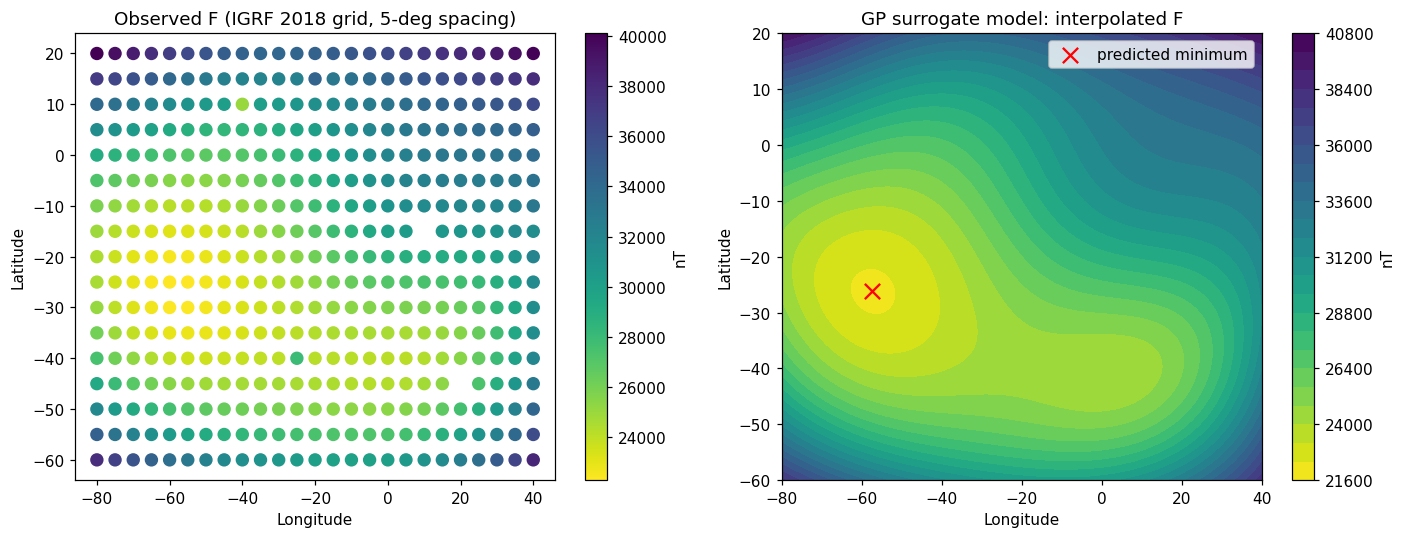

In [32]:
# Chart 4: raw 5-deg grid (left) vs. the GP's fine-grid reconstruction
# With the located SAA minimum marked (right).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter = axes[0].scatter(df.lon, df.lat, c=df[TARGET], cmap="viridis_r", s=60)
axes[0].set_title(f"Observed {TARGET} (IGRF 2018 grid, 5-deg spacing)")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
plt.colorbar(scatter, ax=axes[0], label="nT")

contour = axes[1].contourf(lon_grid, lat_grid, predicted_field, levels=25, cmap="viridis_r")
axes[1].scatter([min_lon], [min_lat], color="red", marker="x", s=100, label="predicted minimum")
axes[1].set_title("GP surrogate model: interpolated " + TARGET)
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
axes[1].legend()
plt.colorbar(contour, ax=axes[1], label="nT")

plt.tight_layout()
plt.savefig("chart4_observed_vs_interpolated.png", dpi=140)
plt.show()

## Step 6: Regional-residual separation

This is a standard exploration-geophysics technique, applied here for the
first time on this dataset. The observed field is a mix of two things: a
broad, slowly-varying **regional trend** (mostly the planetary-scale main
field), and smaller-scale **local anomalies** riding on top of it. In
magnetic exploration, it's the local anomalies — not the regional trend
that tell you about basement structure, faults, and geological boundaries.

The regional trend is estimated here with a simple low-order polynomial
surface fit (degree 2 in latitude and longitude). Subtracting that trend
from the interpolated field leaves the **residual anomaly map**: what's left
over after the large-scale background is removed.


In [34]:
# Fit a degree-2 polynomial trend surface to the observed points (least squares):
# F ~ a0 + a1*lat + a2*lon + a3*lat^2 + a4*lon^2 + a5*lat*lon
A = np.column_stack([
    np.ones_like(X[:, 0]), X[:, 0], X[:, 1],
    X[:, 0] ** 2, X[:, 1] ** 2, X[:, 0] * X[:, 1],
])
coef, *_ = np.linalg.lstsq(A, y, rcond=None)

def regional_trend(lat, lon):
    return (coef[0] + coef[1] * lat + coef[2] * lon
            + coef[3] * lat ** 2 + coef[4] * lon ** 2 + coef[5] * lat * lon)

# Evaluate the trend on the fine grid, then subtract it from the GP
# interpolation to isolate structure the broad trend doesn't explain.
regional_surface = regional_trend(lat_grid, lon_grid)
residual_surface = predicted_field - regional_surface

print(f"Regional trend range: {regional_surface.min():.0f} to {regional_surface.max():.0f} nT")
print(f"Residual anomaly range: {residual_surface.min():.0f} to {residual_surface.max():.0f} nT")

Regional trend range: 23845 to 43407 nT
Residual anomaly range: -3406 to 5496 nT


### Chart 5 — Regional trend vs. residual anomaly

Left: the smooth degree-2 trend surface the large-scale background field. Right: what remains after subtracting it the residual anomaly map. **How to read the residual map:** positive (warm) zones are locally stronger than the regional background; negative (cool) zones, including the SAA itself, are locally weaker. In real exploration work, this residual map not the raw field is what gets handed to a structural geologist, because it strips out the broad-scale signal and keeps the local variation that correlates with subsurface structure.

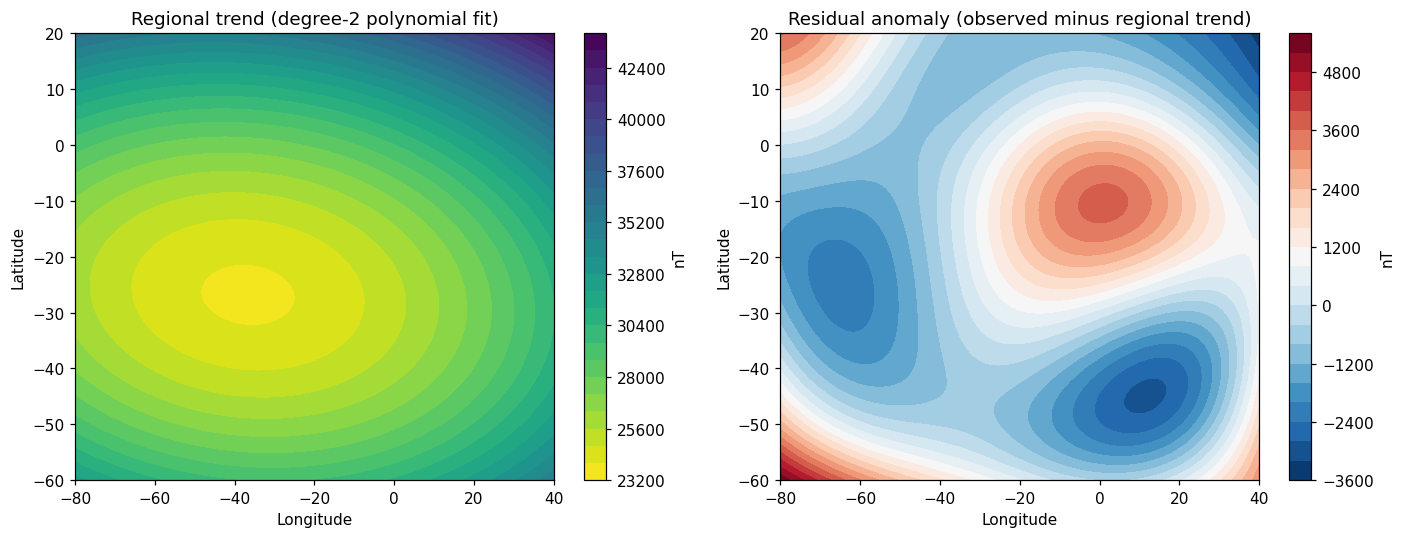

In [36]:
# Chart 5: regional trend surface (left) vs. the residual anomaly map (right).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

c1 = axes[0].contourf(lon_grid, lat_grid, regional_surface, levels=25, cmap="viridis_r")
axes[0].set_title("Regional trend (degree-2 polynomial fit)")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
plt.colorbar(c1, ax=axes[0], label="nT")

c2 = axes[1].contourf(lon_grid, lat_grid, residual_surface, levels=25, cmap="RdBu_r")
axes[1].set_title("Residual anomaly (observed minus regional trend)")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
plt.colorbar(c2, ax=axes[1], label="nT")

plt.tight_layout()
plt.savefig("chart5_regional_residual.png", dpi=140)
plt.show()

## Step 7: Horizontal gradient magnitude — edge / boundary mapping

The horizontal gradient of a magnetic field map is a workhorse technique in
exploration geophysics: it measures how *fast* the field changes from point
to point. Gentle, gradual change usually means you're looking at a broad,
deep source (or no structure at all); a sharp, localised spike in the
gradient usually marks a boundary a fault, an intrusion edge, or a change
in basement rock type because those geological contacts create abrupt
changes in the magnetic properties of the rock.


In [69]:
# Horizontal gradient magnitude of the interpolated surface:
# |grad F| = sqrt((dF/dlat)^2 + (dF/dlon)^2), via finite differences.
dlat = lat_fine[1] - lat_fine[0]
dlon = lon_fine[1] - lon_fine[0]
grad_lat, grad_lon = np.gradient(predicted_field, dlat, dlon)
gradient_magnitude = np.sqrt(grad_lat ** 2 + grad_lon ** 2)

print(f"Gradient magnitude range: {gradient_magnitude.min():.1f} to {gradient_magnitude.max():.1f} nT/deg")

Gradient magnitude range: 2.2 to 739.3 nT/deg


### Chart 6 — Horizontal gradient magnitude map

Brighter zones mark where the field changes fastest across space the candidate boundaries a geophysicist would flag for follow-up. 
**The anomaly's flat core sits inside the darkest (lowest-gradient) region, exactly as expected slow change at the centre of a broad bowl. A band of elevated gradient rings that core, consistent with the anomaly's structural edge.**  The brightest values, however, sit right at the four corners of the mapped domain: this is a boundary artifact of the Gaussian Process extrapolating beyond the support of the actual data, not a real geological signal, and is a standard caveat to flag whenever gradient maps are computed near the edge of a survey's coverage in a real exploration project, gradients would only be trusted well inside the surveyed area.

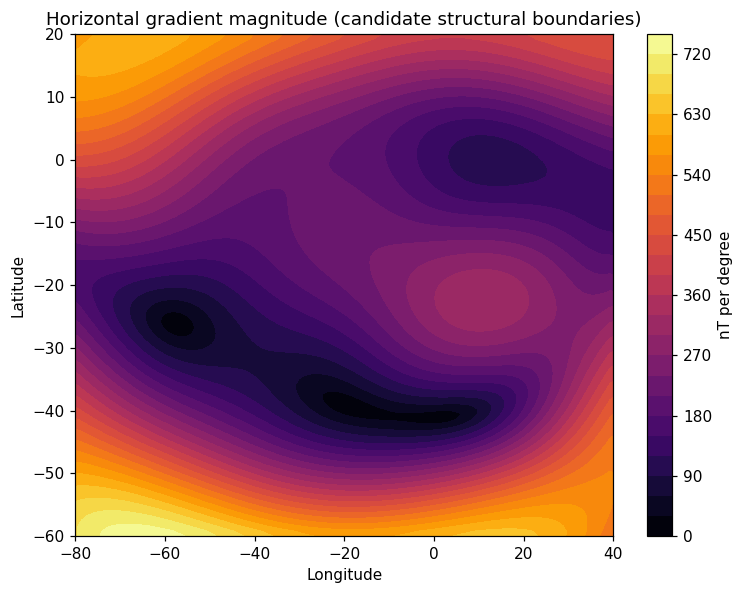

In [40]:
# Chart 6: horizontal gradient magnitude — highlights candidate structural
# boundaries, but note the corners are extrapolation artifacts (see write-up)
fig, ax = plt.subplots(figsize=(7, 5.5))
c = ax.contourf(lon_grid, lat_grid, gradient_magnitude, levels=25, cmap="inferno")
ax.set_title("Horizontal gradient magnitude (candidate structural boundaries)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.colorbar(c, ax=ax, label="nT per degree")
plt.tight_layout()
plt.savefig("chart6_gradient_magnitude.png", dpi=140)
plt.show()

## Summary

**What was built:**
- A cleaned, model-ready dataset from a raw, human-formatted IGRF spreadsheet (425 grid points, 2 removed as data-entry errors).
- A Gaussian Process (Kriging-equivalent) surrogate model, ~296 nT cross-validated RMSE (~1% of the regional mean field) clearly beating a Random Forest baseline, confirmed with out-of-sample predicted-vs-actual and residual diagnostics.
- Automatic localisation of the South Atlantic Anomaly minimum (~26°S, 57°W), matching its documented position in the literature.
- A regional-residual separation, isolating local field variation from the broad planetary-scale background.
- A horizontal-gradient (edge-detection) map, highlighting the anomaly's structural boundary.

**How this generalises to an oil & gas exploration workflow:** the exact same
pipeline grid sparse survey data → interpolate with a Kriging-equivalent
model → separate regional trend from residual → compute gradients to find
edges is standard practice when working with real aeromagnetic or gravity
survey data over a sedimentary basin. The only thing that would change moving
from this notebook to an operational exploration project is the input data:
which is to swap the IGRF reference grid for a licensed high-resolution aeromagnetic
survey.

**Honest limitation:** the IGRF main field captures planetary-scale structure,
not the short-wavelength crustal signal a real exploration survey measures
so the specific anomaly found here (the SAA) is a core-driven feature, not a
sedimentary-basin target. This notebook demonstrates the *method*; applying
it to a real exploration decision requires real high-resolution survey data
as input.